In [43]:
%load_ext autoreload
%autoreload 2

from SRC.pairs_trading import PairsBacktest
from SRC.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
tickers = ['GOOGL', 'NVDA', 'MSFT', 'META', 'TSLA']
years = 170/365

In [45]:
loader = DataLoader(years)
loader.market_data(years, tickers)


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


In [46]:
%%capture
# Initialize the backtester
backtester = PairsBacktest(years, tickers, lookback_window=20, entry_z=-0.1)

ticker_a = loader.ticker_a
ticker_b = loader.ticker_b
results = backtester.compute_metrics()


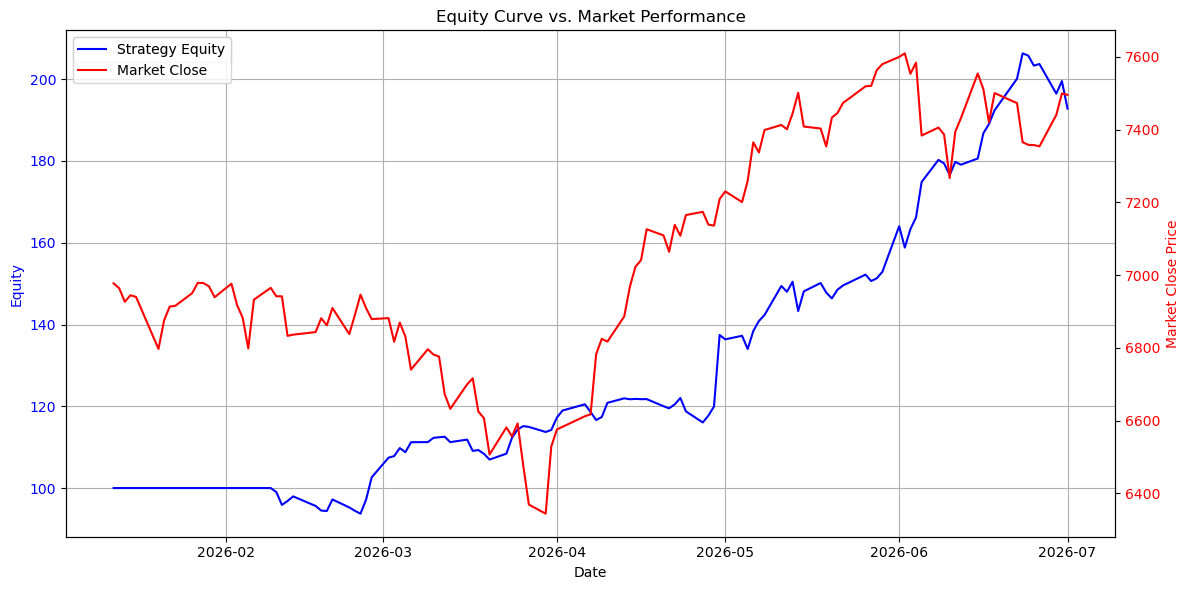

The tickers with the highest correlation, and the ones used in the pairs-trading strategy were NVDA and GOOGL. This strategy used a z-score level of -0.1.
             Metric       Value
0      Sharpe Ratio     4.05002
1             Alpha  160.06678%
2      Total Return      92.80%
3      Max Drawdown      -6.55%
4        Start Date  2026-01-12
5          End Date  2026-07-01
6  Starting Capital     $100.00
7    Ending Capital     $192.80
8    Capital Gained      $92.80
9      Total Trades          98


In [47]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Equity Curve on primary y-axis
sns.lineplot(x=backtester.data.index, y=backtester.data['Equity'], ax=ax1, color='blue', label='Strategy Equity')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Market Data
ax2 = ax1.twinx()
sns.lineplot(x=backtester.market_data.index, y=backtester.market_data['Close'].squeeze(), ax=ax2, color='red', label='Market Close')
ax2.set_ylabel('Market Close Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Equity Curve vs. Market Performance')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The tickers with the highest correlation, and the ones used in the pairs-trading strategy were {ticker_a} and {ticker_b}. This strategy used a z-score level of {backtester.entry_z}.")
print(results)

In [48]:
strat_data = backtester.data

In [49]:
strat_data.to_excel('trades_taken.xlsx', index=False)